## 1번 문제

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
data = load_diabetes()

print(data.keys())

df_x = data.data
df_y = data.target

df_x.shape

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


(442, 10)

In [44]:
x = np.array(df_x)
y = np.array(df_y)
print(x[:3], x.dtype)
print(y[:3], y.dtype)

[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]] float64
[151.  75. 141.] float64


In [45]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)


(353, 10) (89, 10)


In [55]:
w = np.random.rand(x_train.shape[1])
b = np.random.rand()

def model(x, w, b):
    pred = 0
    for i in range(len(w)):
        pred += x[:, i] * w[i]
    pred = pred + b
    return pred

from sklearn.metrics import mean_squared_error

def loss(x, w, b, y):
    pred = model(x, w, b)
    L = mean_squared_error(pred, y)
    return L

def grad(x, w, b, t):
    n = len(y)
    y_pred = model(x, w, b)
    dW = 1/n*2*x.T.dot(y_pred - y)
    db = 2*(y_pred - y).mean()
    return dW, db

LR = 0.001   # Learning Rate

In [57]:
# %%timeit -n 1 -r 1

global w, b

losses = []

for i in range(1, 1001):
    dW, db = grad(x_train, w, b, y_train)
    W -= LR * dW
    b -= LR * db
    L = loss(x_train, w, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print(f'학습횟수 {i} : Loss {L:0.4f}')


ValueError: operands could not be broadcast together with shapes (353,) (442,) 

## 2번 문제

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv")
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [4]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [2]:
train['datetime'] = pd.to_datetime(train['datetime'])   #str 데이터를 date 타입으로 변경
train['year'] = train['datetime'].dt.year               #date 데이터에서 년, 월, 일, 시, 분, 초 수치를 별도 컬럼으로 추가
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

In [3]:
train.shape
train.head(3)     # 추가된 컬럼 내용을 샘플 확인

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0


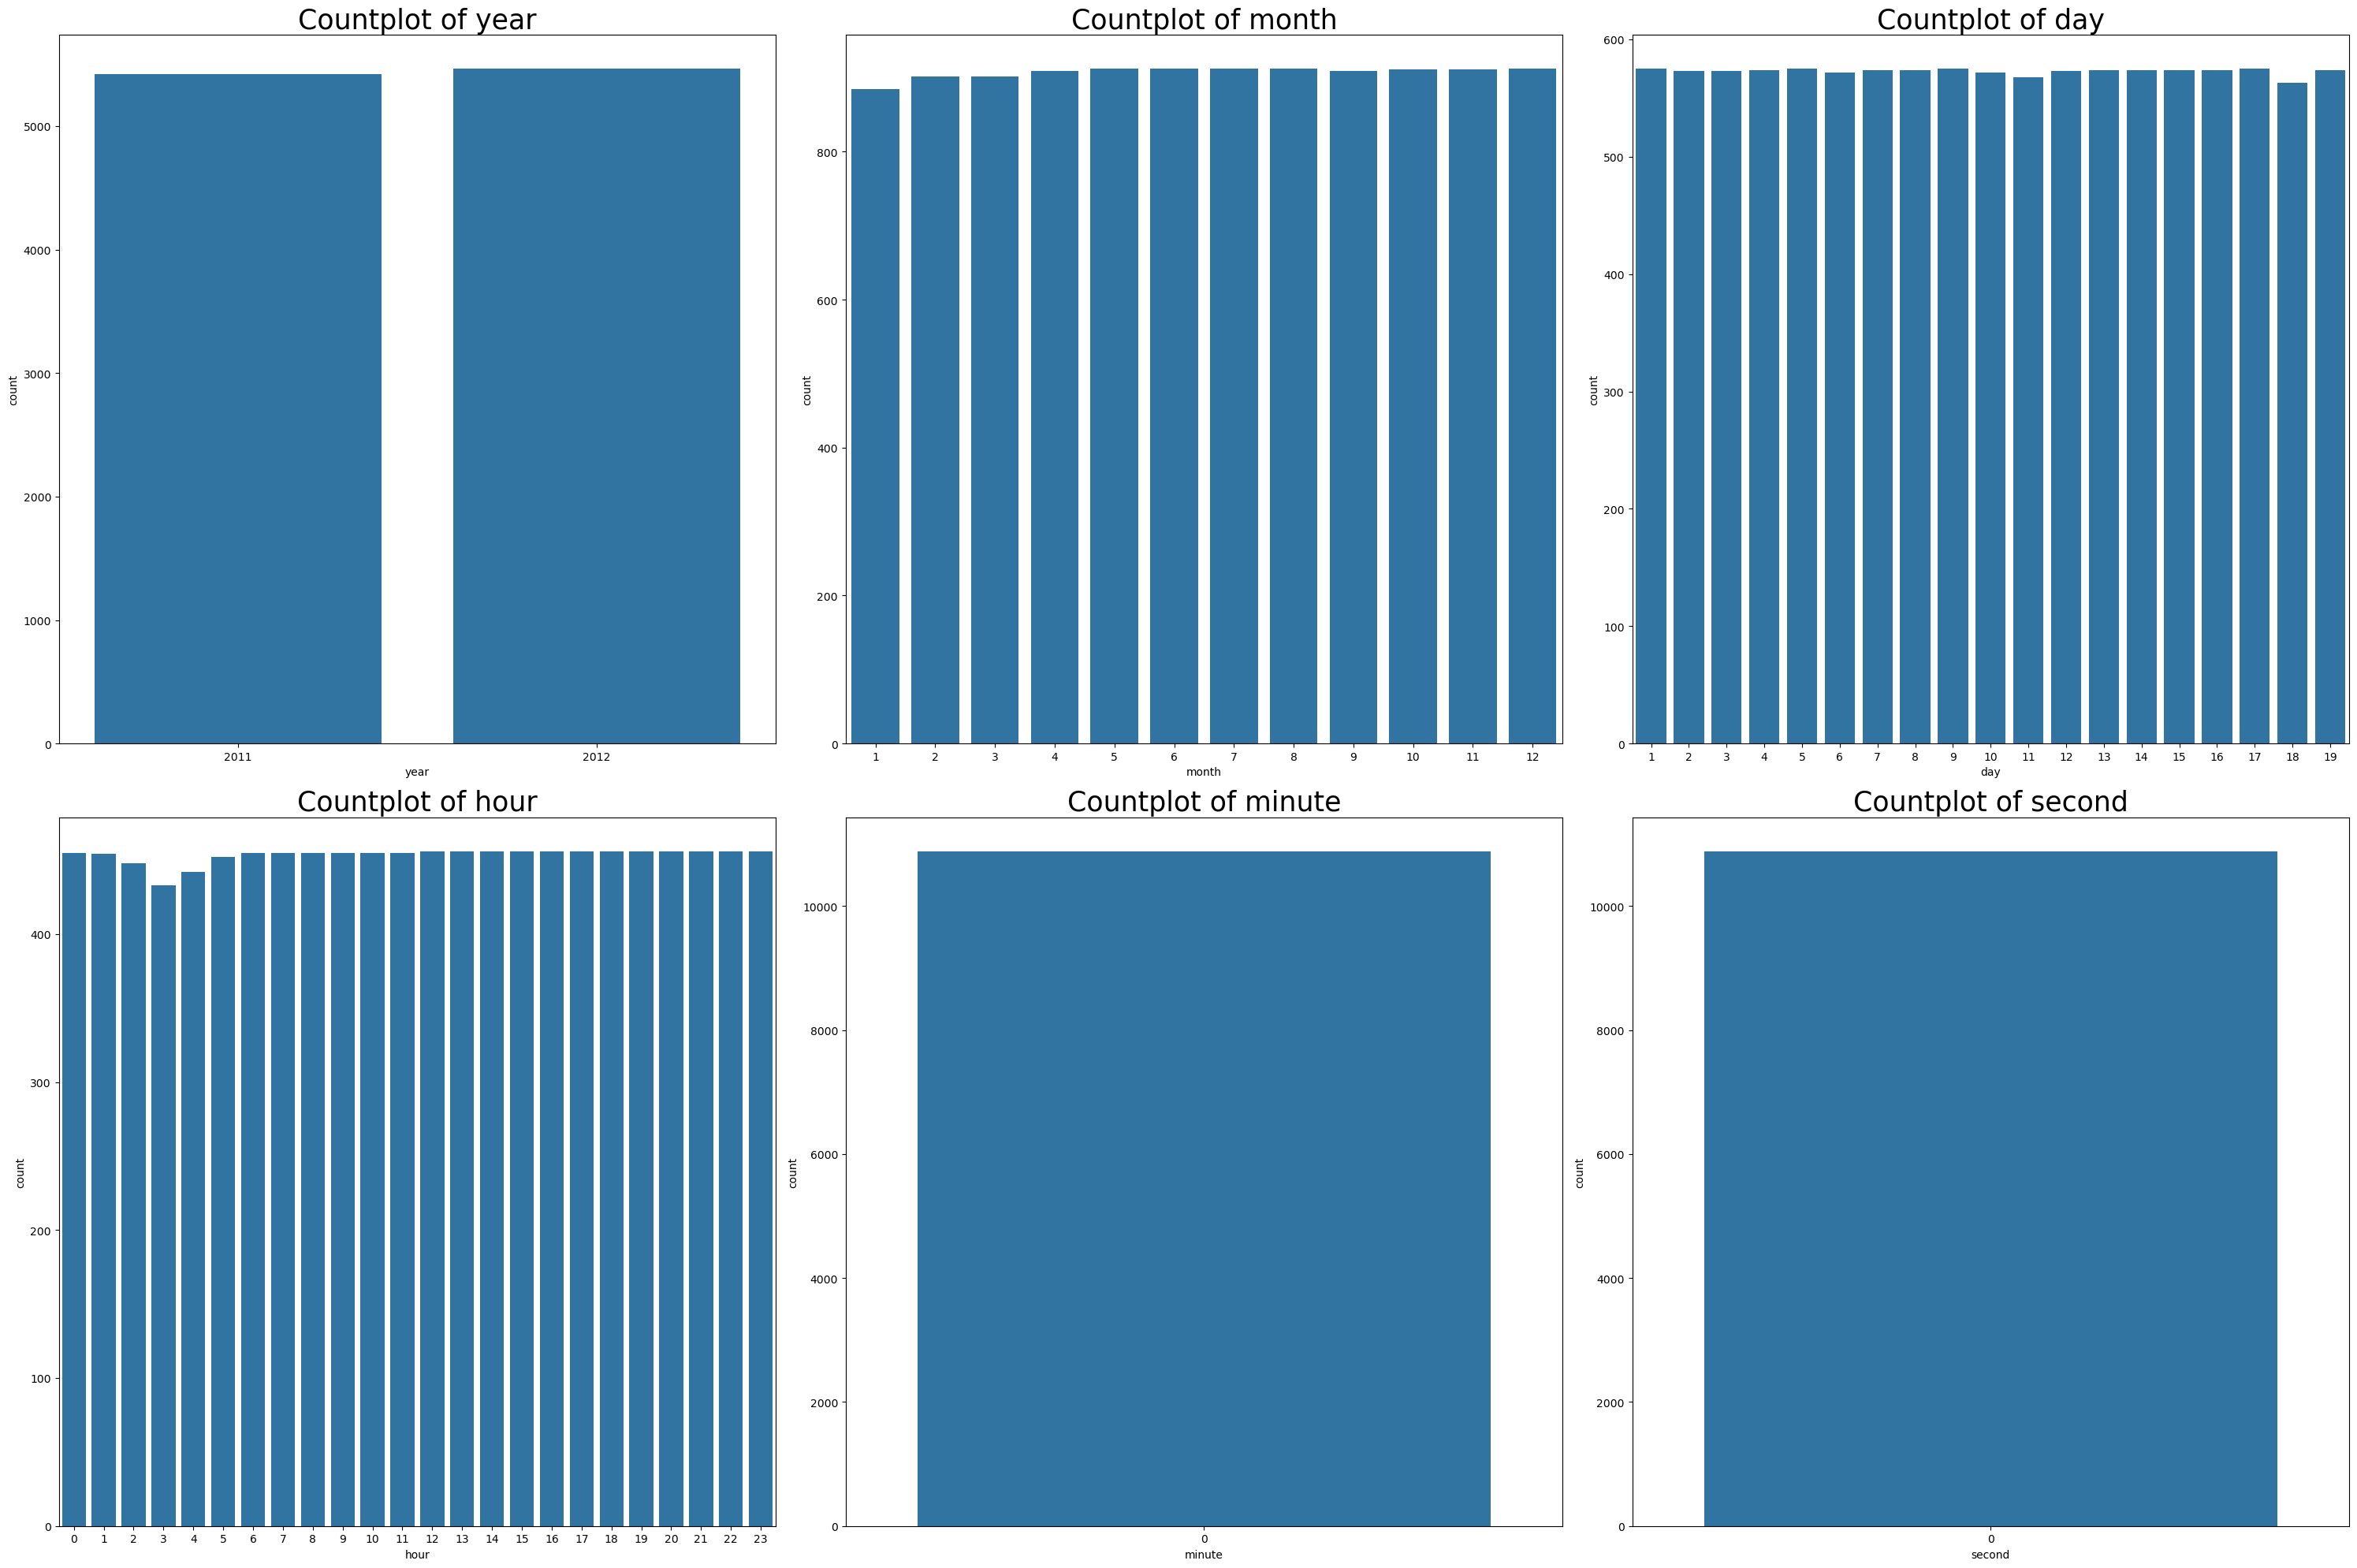

In [6]:
fig, axes = plt.subplots(2,3, figsize=(30,20))     #화면을 2x3 으로 나누고 크기를 설
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']

for ax, col in zip(axes.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}', fontdict={'fontsize':25})
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.model import LinearRegression
from sklearn.metrics import mean_squared_error

features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)



# y_pred = model.predict(X_test)
# mse_train = mean_squared_error(y_pred, y_train)

ModuleNotFoundError: No module named 'sklearn.model'

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(20, 10))

#첫번째 axes, 온도-count 시각화
axes[0].scatter(X_test['temp'], y_test, color='blue', label='Train')
axes[0].scatter(X_test['temp'], y_pred, color='red', label='Predict', alpha=0.5)
axes[0].set_xlabel('temp')
axes[0].set_ylabel('count')
axes[0].set_title('Temperature - Count', fontdict={'fontsize':30))
axes[0].legend()


#두번째 axes, 습도-count 시각화
axes[1].scatter(X_test['humidity'], y_test, color='blue', label='Train')
axes[1].scatter(X_test['humidity'], y_pred, color='red', label='Predict', alpha=0.5)
axes[1].set_xlabel('humidity')
axes[1].set_ylabel('count')
axes[1].set_title('Humidity - Count', fontdict={'fontsize':30))
axes[1].legend()
